# 01 · Preprocessing y auditoría del dataset

Este notebook ejecuta `preprocess_dataset.py` sobre `data/results_no_meta.json` y visualiza la composición general del dataset antes de construir cualquier representación molecular.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data' / 'results_no_meta.json').exists() and (candidate / 'transferability').exists():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del repositorio')

REPO_ROOT = find_repo_root()
TRANSFERABILITY = REPO_ROOT / 'transferability'
SCRIPT = TRANSFERABILITY / 'scripts' / 'preprocess_dataset.py'
RECORDS = TRANSFERABILITY / 'data' / 'preprocessing' / 'records.csv'
SUMMARY = TRANSFERABILITY / 'data' / 'preprocessing' / 'dataset_summary.json'
print(f'Repositorio: {REPO_ROOT}')

Repositorio: /Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis


## Ejecutar preprocessing

La salida compacta evita tener que explorar repetidamente los 182 MB del JSON original.

In [2]:
completed = subprocess.run(
    [sys.executable, str(SCRIPT)],
    cwd=REPO_ROOT,
    text=True,
    capture_output=True,
    check=True,
)
print(completed.stdout)

{
  "source": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/data/results_no_meta.json",
  "records_table": "/Users/cristellemadrid/Desktop/Transformers/transformers-transfer-fine-tuning-thesis/transferability/data/preprocessing/records.csv",
  "records": 480,
  "converged": 480,
  "unique_formulas": 80,
  "records_per_formula": {
    "6": 80
  },
  "calculations": {
    "gga-relax": 240,
    "gga-static": 240
  },
  "prototypes": {
    "dist_perovskite": 160,
    "hexagonal": 160,
    "needle": 160
  },
  "magnetic_orders": {
    "fm": 198,
    "nm": 282
  },
  "n_sites": {
    "20": 480
  },
  "targets": {
    "energy_per_atom": {
      "min": -6.6839963835,
      "mean": -5.196744251479166,
      "median": -5.323547975,
      "max": -3.2907868825
    },
    "relaxed_energy_per_atom": {
      "min": -6.6839433679999996,
      "mean": -5.196386834260417,
      "median": -5.3230928330000005,
      "max": -3.307797132
    },
    "bandgap": {
      

In [3]:
records = pd.read_csv(RECORDS)
summary = json.loads(SUMMARY.read_text())

pd.DataFrame({
    'valor': [
        summary['records'],
        summary['converged'],
        summary['unique_formulas'],
        records['prototype'].nunique(),
        records['calculation'].nunique(),
    ]
}, index=['registros', 'convergidos', 'fórmulas únicas', 'prototipos', 'tipos de cálculo'])

,valor
registros,480
convergidos,480
fórmulas únicas,80
prototipos,3
tipos de cálculo,2


## Balance del dataset

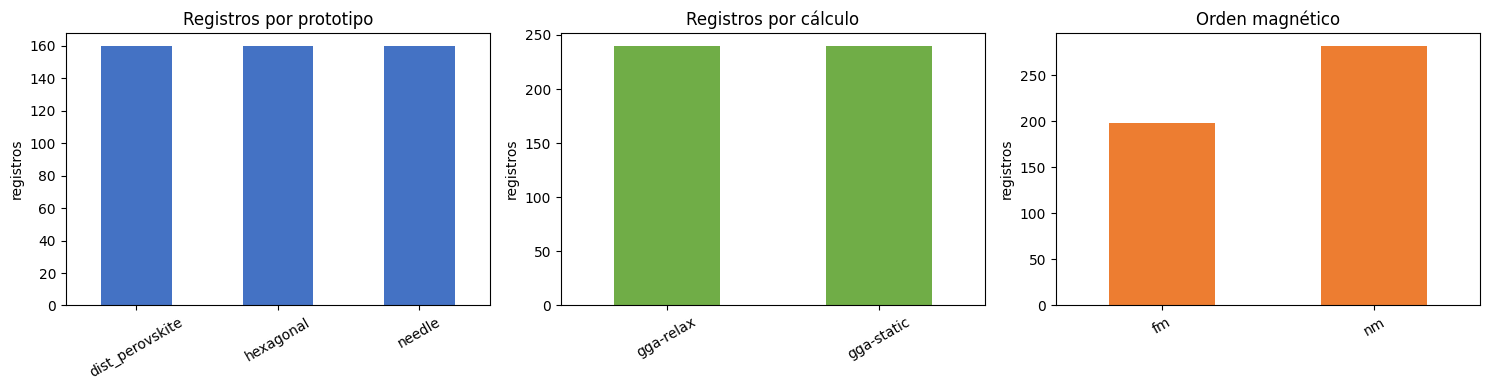

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
records['prototype'].value_counts().sort_index().plot.bar(ax=axes[0], color='#4472C4')
axes[0].set(title='Registros por prototipo', xlabel='', ylabel='registros')
records['calculation'].value_counts().sort_index().plot.bar(ax=axes[1], color='#70AD47')
axes[1].set(title='Registros por cálculo', xlabel='', ylabel='registros')
records['magnetic_order'].value_counts().sort_index().plot.bar(ax=axes[2], color='#ED7D31')
axes[2].set(title='Orden magnético', xlabel='', ylabel='registros')
for axis in axes:
    axis.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

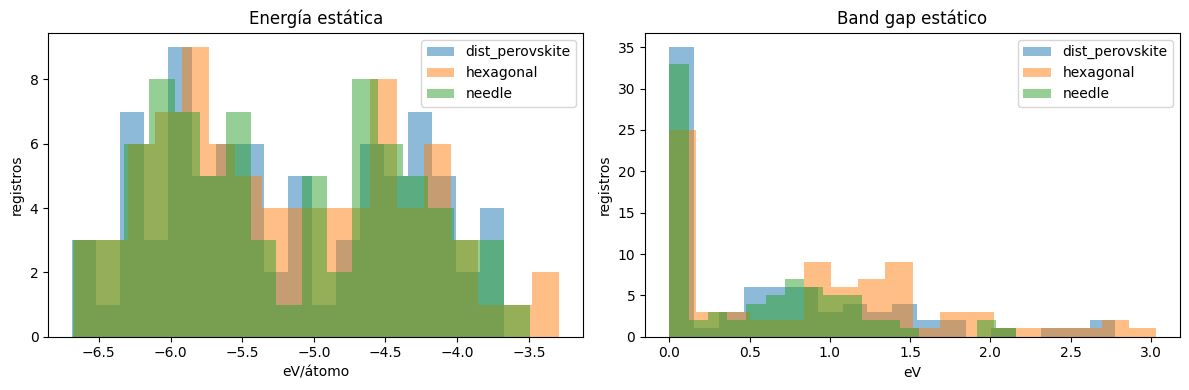

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for prototype, group in records[records['calculation'] == 'gga-static'].groupby('prototype'):
    axes[0].hist(group['energy_per_atom'], bins=18, alpha=0.5, label=prototype)
    axes[1].hist(group['bandgap'], bins=18, alpha=0.5, label=prototype)
axes[0].set(title='Energía estática', xlabel='eV/átomo', ylabel='registros')
axes[1].set(title='Band gap estático', xlabel='eV', ylabel='registros')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

## Muestra de la tabla preprocesada

In [6]:
records.head(10)

,record_id,formula,prototype,magnetic_order,calculation,converged,n_sites,volume,energy_per_atom,relaxed_energy_per_atom,bandgap,is_direct_gap
0,Ba1Ge1S3--Ba1Ge1S3_dist_perovskite--nm--gga-relax,Ba1Ge1S3,dist_perovskite,nm,gga-relax,True,20,501.821901,-4.759775,-4.759775,0.5617,True
1,Ba1Ge1S3--Ba1Ge1S3_dist_perovskite--nm--gga-st...,Ba1Ge1S3,dist_perovskite,nm,gga-static,True,20,501.821901,-4.761982,-4.759775,0.5634,True
2,Ba1Ge1S3--Ba1Ge1S3_hexagonal--nm--gga-relax,Ba1Ge1S3,hexagonal,nm,gga-relax,True,20,591.806543,-4.815511,-4.815511,2.0916,False
3,Ba1Ge1S3--Ba1Ge1S3_hexagonal--nm--gga-static,Ba1Ge1S3,hexagonal,nm,gga-static,True,20,591.806543,-4.819379,-4.815511,2.0916,False
4,Ba1Ge1S3--Ba1Ge1S3_needle--nm--gga-relax,Ba1Ge1S3,needle,nm,gga-relax,True,20,471.757929,-4.690139,-4.690139,0.4274,False
5,Ba1Ge1S3--Ba1Ge1S3_needle--nm--gga-static,Ba1Ge1S3,needle,nm,gga-static,True,20,471.757929,-4.690243,-4.690139,0.4273,False
6,Ba1Hf1S3--Ba1Hf1S3_dist_perovskite--nm--gga-relax,Ba1Hf1S3,dist_perovskite,nm,gga-relax,True,20,497.924308,-6.683943,-6.683943,1.2652,True
7,Ba1Hf1S3--Ba1Hf1S3_dist_perovskite--nm--gga-st...,Ba1Hf1S3,dist_perovskite,nm,gga-static,True,20,497.924308,-6.683996,-6.683943,1.2651,True
8,Ba1Hf1S3--Ba1Hf1S3_hexagonal--nm--gga-relax,Ba1Hf1S3,hexagonal,nm,gga-relax,True,20,515.260302,-6.674830,-6.674830,1.1427,True
9,Ba1Hf1S3--Ba1Hf1S3_hexagonal--nm--gga-static,Ba1Hf1S3,hexagonal,nm,gga-static,True,20,515.260302,-6.674908,-6.674830,1.1427,True
